In [1]:
%pip install SimpleITK==2.4.0
%pip install numpy==1.26.4
%pip install pyradiomics==3.1.0
%pip install nibabel
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packag

In [2]:
# Load MRI modalities using SimpleITK
import SimpleITK as sitk
import os

# Example: Load all modalities for a subject in a folder
def load_mri_modalities(subject_dir, modalities=['flair', 't1', 't1ce', 't2']):
    images = {}
    for modality in modalities:
        # Assumes filenames like: subject_flair.nii.gz, subject_t1.nii.gz, etc.
        for file in os.listdir(subject_dir):
            if modality in file and (file.endswith('.nii') or file.endswith('.nii.gz')):
                img_path = os.path.join(subject_dir, file)
                images[modality] = sitk.ReadImage(img_path)
    return images

# Example usage:
# subject_dir = '/path/to/BraTS2021_00000'
# modalities = load_mri_modalities(subject_dir)
# print(modalities.keys())  # Should show ['flair', 't1', 't1ce', 't2'] if all are present

In [3]:
# Load segmentation mask using SimpleITK
def load_segmentation_mask(subject_dir, mask_suffix='_seg.nii.gz'):
    import os
    import SimpleITK as sitk
    for file in os.listdir(subject_dir):
        if file.endswith(mask_suffix):
            mask_path = os.path.join(subject_dir, file)
            mask = sitk.ReadImage(mask_path)
            return mask
    raise FileNotFoundError(f"No segmentation mask with suffix {mask_suffix} found in {subject_dir}")

# Example usage:
# subject_dir = '/path/to/BraTS2021_00000'
# mask = load_segmentation_mask(subject_dir)
# print(mask.GetSize())

In [4]:
# Enable feature classes in PyRadiomics
from radiomics import featureextractor

# Define the feature classes to enable
feature_classes = [
    'shape',
    'firstorder',
    'glcm',
    'glrlm',
    'glszm',
    'ngtdm',
    'gldm'
]

# Configure extractor parameters using the expected schema.
# PyRadiomics expects settings under the 'setting' key in the params dict.
params = {
    'setting': {
        'binWidth': 25,
        'normalize': True,
        'resampledPixelSpacing': None,
        # Use the SimpleITK interpolator name supported by PyRadiomics
        'interpolator': 'sitkBSpline'
    },
    'featureClass': {cls: [] for cls in feature_classes}
}

extractor = featureextractor.RadiomicsFeatureExtractor(params)
print('Enabled feature classes:', extractor.enabledFeatures.keys())

Enabled feature classes: dict_keys(['shape', 'firstorder', 'glcm', 'glrlm', 'glszm', 'ngtdm', 'gldm'])


In [15]:
# Loop through all patients, extract features, and save to CSV (only original_ features, no complex values)
import pandas as pd
import glob
import os

# Set the dataset directory
base_dir = 'dataset/BraTS2021_Training_Data'
patient_dirs = glob.glob(os.path.join(base_dir, 'BraTS2021_*'))

results = []
for patient_dir in patient_dirs:
    # Load modalities (example: flair)
    images = load_mri_modalities(patient_dir, modalities=['flair'])
    image = images.get('flair')
    if image is None:
        print(f"No flair image for {patient_dir}")
        continue
    # Load mask
    try:
        mask = load_segmentation_mask(patient_dir)
    except FileNotFoundError:
        print(f"No mask for {patient_dir}")
        continue
    # Extract features
    feature_vector = extractor.execute(image, mask)
    # Filter only features starting with 'original_' and convert complex to float
    original_features = {}
    for k, v in feature_vector.items():
        if k.startswith('original_'):
            if isinstance(v, complex):
                v = v.real
            original_features[k] = float(v) if isinstance(v, (int, float)) or isinstance(v, complex) else v
    # Add patient id and features to results
    patient_id = os.path.basename(patient_dir)
    row = {'patient_id': patient_id}
    row.update(original_features)
    results.append(row)

# Save all results to CSV
df = pd.DataFrame(results)
df.to_csv('radiomics_features.csv', index=False)
print('Saved radiomics_features.csv (only original_ features, no complex values)')

GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

Saved radiomics_features.csv (only original_ features, no complex values)


/home/vscode/.local/lib/python3.9/site-packages/radiomics/glcm.py:767: RuntimeWarning: Mean of empty slice
  return numpy.nanmean(sumavg, 1)
/home/vscode/.local/lib/python3.9/site-packages/radiomics/glcm.py:799: RuntimeWarning: Mean of empty slice
  return numpy.nanmean(sumentr, 1)
/home/vscode/.local/lib/python3.9/site-packages/radiomics/glcm.py:827: RuntimeWarning: Mean of empty slice
  return numpy.nanmean(ss, 1)
/home/vscode/.local/lib/python3.9/site-packages/radiomics/glrlm.py:224: RuntimeWarning: Mean of empty slice
  return numpy.nanmean(gln, 1)
/home/vscode/.local/lib/python3.9/site-packages/radiomics/glrlm.py:240: RuntimeWarning: Mean of empty slice
  return numpy.nanmean(glnn, 1)
/home/vscode/.local/lib/python3.9/site-packages/radiomics/glrlm.py:316: RuntimeWarning: Mean of empty slice
  return numpy.nanmean(glv, 1)
/home/vscode/.local/lib/python3.9/site-packages/radiomics/glrlm.py:389: RuntimeWarning: Mean of empty slice
  return numpy.nanmean(hglre, 1)
/home/vscode/.local/l

In [6]:
# Group extracted features by class prefix and save grouping dictionary
import json

# Load the feature CSV to get column names
feature_df = pd.read_csv('radiomics_features.csv')
feature_columns = feature_df.columns.tolist()

# Define class prefixes
prefixes = ['shape_', 'firstorder_', 'glcm_', 'glrlm_', 'glszm_', 'ngtdm_', 'gldm_']

# Group features by prefix
grouping = {prefix[:-1]: [] for prefix in prefixes}
for col in feature_columns:
    for prefix in prefixes:
        if col.startswith(prefix):
            grouping[prefix[:-1]].append(col)

# Save grouping dictionary to JSON
with open('feature_grouping.json', 'w') as f:
    json.dump(grouping, f, indent=2)
print('Saved feature_grouping.json')

Saved feature_grouping.json


In [9]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/13.5 MB ? eta -:--:--  Downloading scikit_learn-1.6.1-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.5 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 18.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 18.6 MB/s eta 0:00:00
     ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/38.6 MB 52.6 MB/s eta 0:00:01  Downloading scipy-1.13.1-cp39-cp39-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 22.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 22.2 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/308.4 kB ? eta -:--:--Collecting joblib>=1.2.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 14.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/3

In [17]:
# Train RandomForestClassifier and evaluate (Accuracy, F1, CV score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Load features
df = pd.read_csv('radiomics_features.csv')

# Example: Assume 'label' column exists for classification
target_col = 'label'
if target_col not in df.columns:
    raise ValueError("'label' column not found in radiomics_features.csv. Please add your target labels.")

X = df.drop(['patient_id', target_col], axis=1)
y = df[target_col]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
cv = cross_val_score(clf, X, y, cv=5).mean()

print(f'Accuracy: {acc:.4f}')
print(f'F1 Score: {f1:.4f}')
print(f'CV Score (5-fold): {cv:.4f}')

Accuracy: 0.5000
F1 Score: 0.3333
CV Score (5-fold): 0.8000


In [18]:
# Compare feature classes: RF with each group, CV=5, store comparison table
# Load grouping dictionary
with open('feature_grouping.json', 'r') as f:
    grouping = json.load(f)

comparison = []
for group, features in grouping.items():
    if not features:
        continue
    X_group = df[features]
    # 5-fold cross-validation
    scores = cross_val_score(clf, X_group, y, cv=5)
    comparison.append({
        'feature_class': group,
        'cv_mean': np.mean(scores),
        'cv_std': np.std(scores),
        'n_features': len(features)
    })

comparison_df = pd.DataFrame(comparison)
comparison_df.to_csv('class_performance.csv', index=False)
print('Saved class_performance.csv')
display(comparison_df)

Saved class_performance.csv


""


In [22]:
%pip install matplotlib
%pip install seaborn

723.56s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


729.45s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/294.9 kB 950.8 kB/s eta 0:00:01  Downloading seaborn-0.13.2-py3-none-any.whl (294 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 1.9 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 1.9 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Saved feature_importance.csv


/tmp/ipykernel_8183/3439155279.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_clean = X.applymap(_to_scalar)


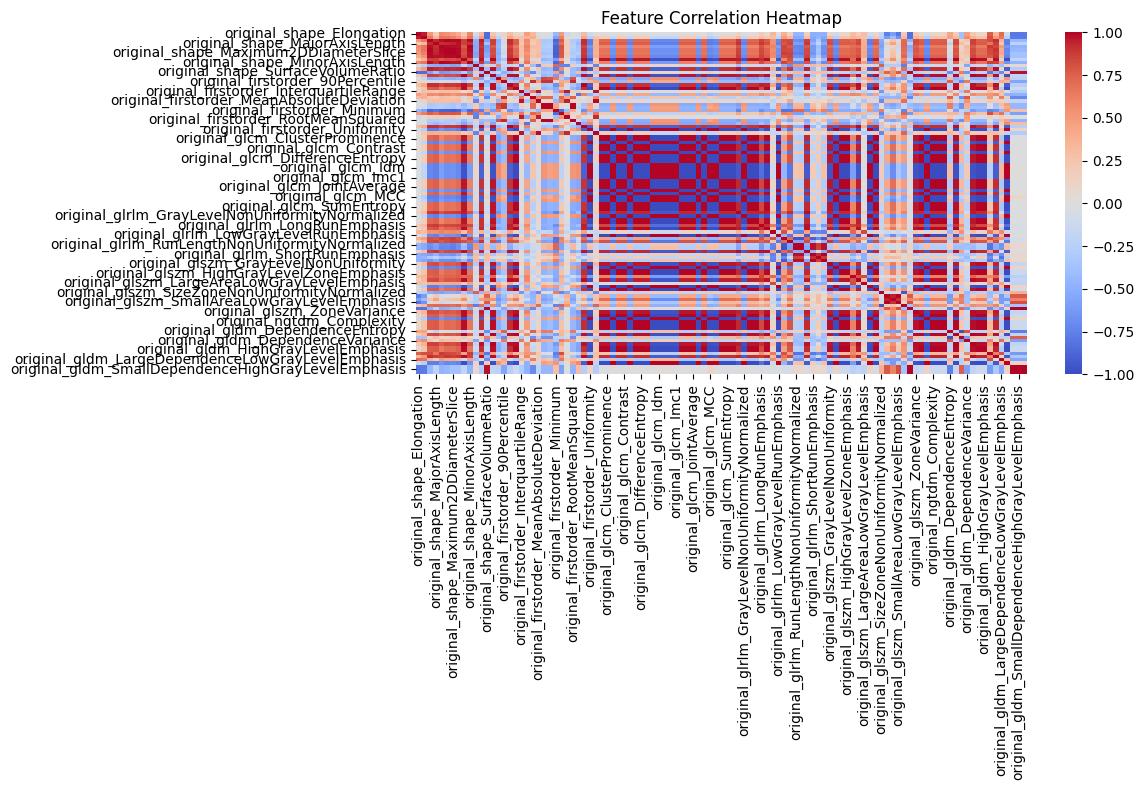

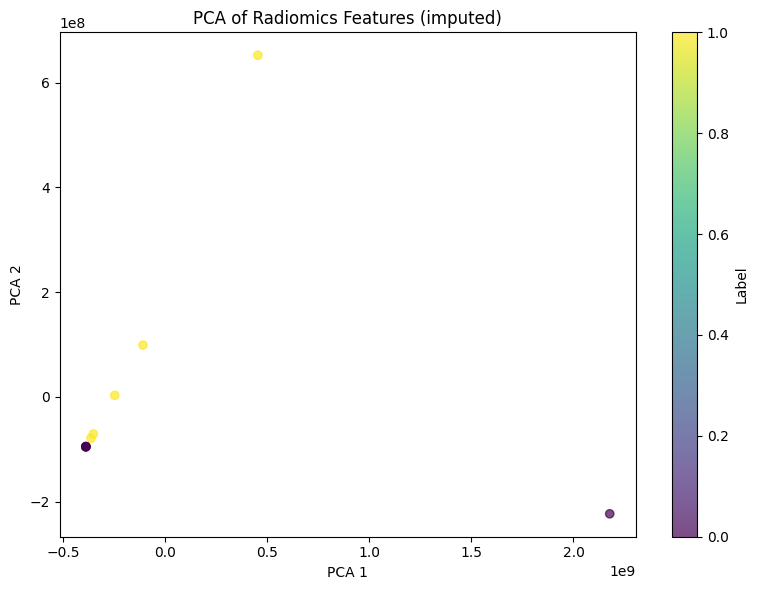

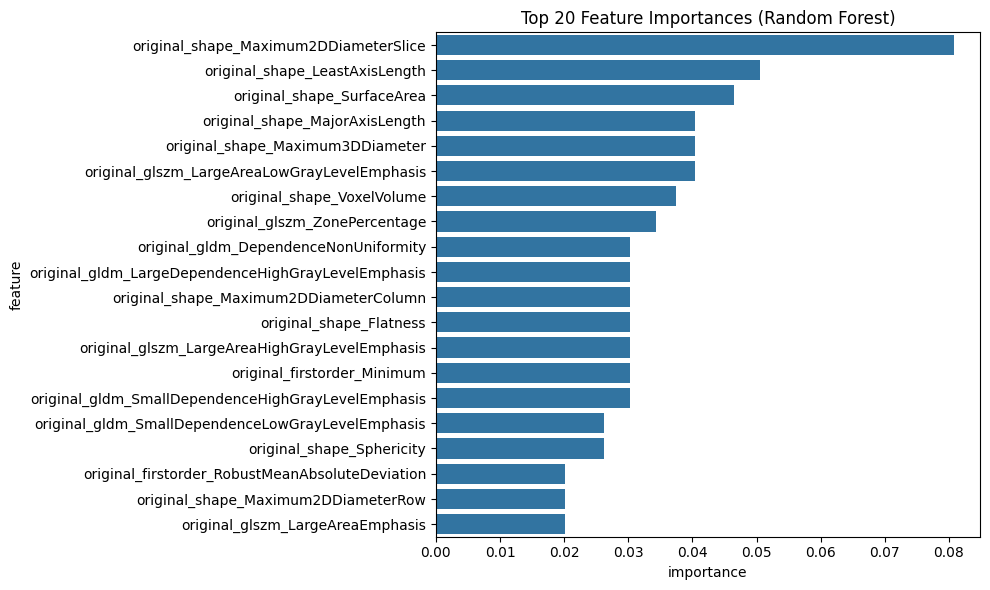

In [24]:
# Save feature importances and create visualizations (heatmap, PCA, RF importance)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# Save feature importances from the main RF model
importances = clf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)
importance_df.to_csv('feature_importance.csv', index=False)
print('Saved feature_importance.csv')

# Prepare X for plotting/PCA: convert any array-like / complex entries to scalars and impute NaNs.
def _to_scalar(v):
	# try to turn array-like with single element into float, handle complex -> real, otherwise float conversion
	if isinstance(v, complex):
		return v.real
	try:
		arr = np.asarray(v)
		if arr.size == 1:
			return float(arr)
	except Exception:
		pass
	try:
		return float(v)
	except Exception:
		return np.nan

# Convert all cells to scalars where possible
X_clean = X.applymap(_to_scalar)

# Drop columns that are entirely NaN (cannot be imputed meaningfully)
all_nan_cols = X_clean.columns[X_clean.isna().all()].tolist()
if all_nan_cols:
	print(f"Dropping columns with all NaN: {all_nan_cols}")
	X_clean = X_clean.drop(columns=all_nan_cols)

# Impute remaining NaNs with column mean
imputer = SimpleImputer(strategy='mean')
X_imputed_arr = imputer.fit_transform(X_clean)
X_imputed = pd.DataFrame(X_imputed_arr, columns=X_clean.columns, index=X_clean.index)

# Heatmap of feature correlation (use imputed data)
plt.figure(figsize=(12, 8))
corr = X_imputed.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# PCA plot (first two components) -- use imputed numeric matrix
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_imputed)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA of Radiomics Features (imputed)')
plt.colorbar(scatter, label='Label')
plt.tight_layout()
plt.show()

# Plot top 20 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()